In [1]:
# Al inicio del notebook, agregar estas líneas:
%load_ext autoreload
%autoreload 2

import matplotlib.image as mpimg
import numpy as np
import subprocess
import pickle
import shutil
import sys
import os
import concurrent

from datetime import datetime
from pathlib import Path


from RRAM import Representate

In [2]:
ruta_raiz = os.getcwd() + "/"
print("Ruta raiz del proyecto:", ruta_raiz)
sys.path.append(ruta_raiz)

# Ruta proporcionada
ruta_exp_data = ruta_raiz + "Datos_Experimentales/Ciclos_Experimentales"
ruta_init_data = ruta_raiz + "Initial_data/"

# Función para borrar y crear una carpeta de forma segura
def safe_reset_folder(folder_path):
    # Evita borrar carpetas peligrosas como la raíz del usuario
    if folder_path.strip().lower() in [
        "c:/users/usuario",
        "c:\\users\\usuario",
        "c:/users",
        "c:\\users",
    ]:
        print(f"ADVERTENCIA: No se permite borrar la carpeta protegida: {folder_path}")
        return
    try:
        if os.path.exists(folder_path):
            shutil.rmtree(folder_path)
        os.makedirs(folder_path)
    except PermissionError as e:
        print(
            f"Error de permisos al intentar borrar o crear la carpeta: {folder_path}\n{e}"
        )
    except Exception as e:
        print(f"Error inesperado con la carpeta: {folder_path}\n{e}")

# Borro los datos iniciales de la simulación anterior de forma segura
safe_reset_folder(ruta_init_data)

Ruta raiz del proyecto: c:\Users\Usuario\Documents\GitHub\RRAM_Simulation/


In [3]:
# Solicitar la ruta del archivo al usuario
ruta_archivo_set = ruta_exp_data + '/Cycle_p_1000.txt'
ruta_archivo_reset = ruta_exp_data + '/Cycle_n_1000.txt'

# Leer datos del archivo
data_set = np.loadtxt(ruta_archivo_set)
data_reset = np.loadtxt(ruta_archivo_reset)

ruta_init_script = ruta_raiz + 'Init_simulation.py'
ruta_simulation_script = ruta_raiz + 'RRAM_Simulation_exceptions.py'

# Defino la carpeta donde se guardan los datos iniciales de la simulación
carpeta_results = 'Results'

simulation_path = os.path.join(carpeta_results)

# Verifica si la carpeta existe
if os.path.exists(simulation_path):
    # Elimina la carpeta y su contenido
    shutil.rmtree(simulation_path)

    # crea la carpeta
    os.makedirs(simulation_path)
    os.makedirs(simulation_path + '/Figures')

In [4]:
# Creo los vectores y luego los combino para generar los sets de datos a probar
I_0 = [1.8e-3]  # 2e-3
ohm_resistence = [11.5]  # , 9.5 10 10.5
gamma = [8]  # 9 #10, 11, 12]

# Defino los factores de moficiación de la energía de generación y recombinación
factors_set = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

E_a_base = 1.01
E_a = [round(E_a_base * f, 3) for f in factors_set]

factor_generacion = [2]  # 1,1 1,2 funcion bn el bueno es 1.2
r_termica_no_percola = [10]
r_termica_percola = [500]  # , 9e2, 7e2]

factors_reset = [1,1,1,1,1,1,1,1,1,1]

E_r_base = 1.04
E_r = [round(E_r_base * f, 3) for f in factors_reset]

num_oxigenos_pp_reset_1 = [1]
num_oxigenos_pp_reset_2 = [7]
num_oxigenos_sp_reset = [10]

In [5]:
# Generamos la lista de tuplas con la combinación de valores
data = [
    (v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, v11)
    for v1 in gamma
    for v2 in I_0
    for v3 in r_termica_percola
    for v4 in r_termica_no_percola
    for v5 in factor_generacion
    for v6 in ohm_resistence
    for v7 in E_r
    for v8 in E_a
    for v9 in num_oxigenos_sp_reset
    for v10 in num_oxigenos_pp_reset_2
    for v11 in num_oxigenos_pp_reset_1
]

print(data)

# Extraemos los valores usando zip
(
    gamma,
    I_0,
    r_termica_percola,
    r_termica_no_percola,
    factor_generacion,
    ohm_resistence,
    E_r,
    E_a,
    num_oxigenos_sp_reset,
    num_oxigenos_pp_reset_2,
    num_oxigenos_pp_reset_1
) = zip(*data)

# Convertimos a listas nuevamente
I_0 = list(I_0)
ohm_resistence = list(ohm_resistence)
gamma = list(gamma)
E_a = list(E_a)
factor_generacion = list(factor_generacion)
r_termica_no_percola = list(r_termica_no_percola)
r_termica_percola = list(r_termica_percola)
E_r = list(E_r)
num_oxigenos_pp_reset_1 = list(num_oxigenos_pp_reset_1)
num_oxigenos_pp_reset_2 = list(num_oxigenos_pp_reset_2)
num_oxigenos_sp_reset = list(num_oxigenos_sp_reset)

print("ohm_resistence:", ohm_resistence)
print("gamma:", gamma)
print("I_0:", I_0)
print("E_a:", E_a)
print("E_r:", E_r)
print("factor_generacion:", factor_generacion)
print("r_termica_no_percola:", r_termica_no_percola)
print("r_termica_percola:", r_termica_percola)
print("num_oxigenos_pp_reset_1:", num_oxigenos_pp_reset_1)
print("num_oxigenos_pp_reset_2:", num_oxigenos_pp_reset_2)
print("num_oxigenos_sp_reset:", num_oxigenos_sp_reset)

[(8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10, 7, 1), (8, 0.0018, 500, 10, 2, 11.5, 1.04, 1.01, 10,

In [6]:
# Guardo los datos en un archivo pkl
with open(ruta_init_data + 'I_0.pkl', 'wb') as f:
    pickle.dump(I_0, f)

with open(ruta_init_data + 'ohm_resistence.pkl', 'wb') as f:
    pickle.dump(ohm_resistence, f)

with open(ruta_init_data + 'gamma.pkl', 'wb') as f:
    pickle.dump(gamma, f)

with open(ruta_init_data + 'E_a.pkl', 'wb') as f:
    pickle.dump(E_a, f)
    
with open(ruta_init_data + 'factor_generacion.pkl', 'wb') as f:
    pickle.dump(factor_generacion, f)
    
with open(ruta_init_data + 'r_termica_no_percola.pkl', 'wb') as f:
    pickle.dump(r_termica_no_percola, f)
    
with open(ruta_init_data + 'r_termica_percola.pkl', 'wb') as f:
    pickle.dump(r_termica_percola, f)
    
with open(ruta_init_data + 'recombination_energy.pkl', 'wb') as f:
    pickle.dump(E_r, f)
    
with open(ruta_init_data + 'num_oxigenos_pp_reset_1.pkl', 'wb') as f:
    pickle.dump(num_oxigenos_pp_reset_1, f)
    
with open(ruta_init_data + 'num_oxigenos_pp_reset_2.pkl', 'wb') as f:
    pickle.dump(num_oxigenos_pp_reset_2, f)
    
with open(ruta_init_data + 'num_oxigenos_sp_reset.pkl', 'wb') as f:
    pickle.dump(num_oxigenos_sp_reset, f)

In [7]:
# LLamo al script de configuracion que genera los archivos de configuracion
subprocess.run(["python", ruta_init_script, ruta_init_data, str(len(ohm_resistence))])

# Paralelización con hilos (funciona en Jupyter)
num_simulaciones = len(ohm_resistence)

print(f"Se van a ejecutar {num_simulaciones} simulaciones\n")

ruta_raiz = Path.cwd()
carpeta_results = ruta_raiz / "Results"

# Elimino la capreta de resultados anterior
if (carpeta_results).exists():
    shutil.rmtree(carpeta_results)
    carpeta_results.mkdir(parents=True, exist_ok=True)

global_figures_path = Path.cwd() / "Results" / "Figures"
global_figures_path.mkdir(parents=True, exist_ok=True)

Se van a ejecutar 100 simulaciones



In [8]:
path = os.getcwd() + '/'

# Carpeta donde se guardarán los logs
log_dir = "logs"
os.makedirs(log_dir, exist_ok=True)  # Crea la carpeta si no existe

# Limpio la carpeta de logs antes de empezar
for file in os.listdir(log_dir):
    file_path = os.path.join(log_dir, file)
    try:
        if os.path.isfile(file_path):
            os.unlink(file_path)
    except Exception as e:
        print(f"No se pudo eliminar {file_path}. Error: {e}")
# Función que ejecuta una simulación y guarda su propio log

guardar_datos = False  # Cambiado a False para evitar guardar datos de configuracion en cada simulación
num_filametos = 4

def ejecutar_simulacion(num_simulacion):
    log_file_path = os.path.join(log_dir, f"log_simulacion_{num_simulacion + 1}.log")

    with open(log_file_path, 'w') as log_file:
        print(f"Iniciando simulación {num_simulacion+1}")
        subprocess.run(
            [
                "python",
                path + "RRAM_mod_simulation.py",
                str(num_simulacion),
                str(guardar_datos),
                str(num_filametos),
            ],
            stdout=log_file,
            stderr=log_file,
        )

# Paralelización con hilos (funciona en Jupyter)
num_simulaciones = len(ohm_resistence)

print(f"Se van a ejecutar {num_simulaciones} simulaciones:\n")

num_procesadores = int(0.8*(os.cpu_count())) or 12 # type: ignore

with concurrent.futures.ThreadPoolExecutor(
    max_workers=num_procesadores
) as executor:  # Usa hilos en vez de procesos
    executor.map(ejecutar_simulacion, range(num_simulaciones))

print("Todas las simulaciones han terminado")

Se van a ejecutar 100 simulaciones:

Iniciando simulación 1
Iniciando simulación 2
Iniciando simulación 4
Iniciando simulación 5
Iniciando simulación 3
Iniciando simulación 6
Iniciando simulación 7
Iniciando simulación 8
Iniciando simulación 9
Iniciando simulación 10
Iniciando simulación 11
Iniciando simulación 12
Iniciando simulación 13
Iniciando simulación 14
Iniciando simulación 15
Iniciando simulación 16
Iniciando simulación 17
Iniciando simulación 18
Iniciando simulación 19
Iniciando simulación 20
Iniciando simulación 21
Iniciando simulación 22
Iniciando simulación 23
Iniciando simulación 24
Iniciando simulación 25
Iniciando simulación 26
Iniciando simulación 27
Iniciando simulación 28
Iniciando simulación 29
Iniciando simulación 30
Iniciando simulación 31
Iniciando simulación 32
Iniciando simulación 33
Iniciando simulación 34
Iniciando simulación 35
Iniciando simulación 36
Iniciando simulación 37
Iniciando simulación 38
Iniciando simulación 39
Iniciando simulación 40
Iniciando si

In [9]:
num_simulation = 9
simulation_path = Path.cwd() / "Results" / f"Simulation_{num_simulation}"
figures_path = Path.cwd() / "Results" / f"Simulation_{num_simulation}" / "Figures"
# Diccionario de desplazamiento (dx, dy) para cada punto
desplazamiento = {
    "a": (0.025, 1.0),  # derecha, misma altura
    "b": (-0.005, 0.27),  # izquierda, un poco arriba
    "c": (-0.02, 0.35),  # derecha, un poco abajo
    "d": (0.02, 1.0),  # izquierda, misma altura
    "e": (-0.11, 0.66),  # izquierda, misma altura
    "f": (-0.025, 0.25),  # izquierda, un poco abajo
    "g": (-0.12, 0.6),  # derecha, un poco arriba
    "h": (-0.12, 0.6),  # derecha, un poco arriba
    "i": (-0.12, 0.6),  # derecha, un poco arriba
    "j": (-0.12, 0.6),  # derecha, un poco arriba
    "k": (-0.12, 0.6),  # derecha, un poco arriba
}

roturas_dict = {
    0: {"filamento": 1, "voltaje": -1.09746, "etapa": "pp"},
    1: {"filamento": 3, "voltaje": -1.07422, "etapa": "sp"},
    2: {"filamento": 4, "voltaje": -1.02340, "etapa": "sp"},
    3: {"filamento": 2, "voltaje": -0.69818, "etapa": "sp"},
}

voltaje_percolacion = 0.4372

Generando figura para el panel 1-6
c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_1.png
c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_2.png
c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_3.png
c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_4.png
c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_5.png
c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_6.png
Cargando imagen: c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_1.png
Cargando imagen: c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_2.png
Cargando imagen: c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_3.png
Cargando imagen: c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_4.png
Cargando imagen: c:\Users\Usuario\Documents\GitHub\RRAM_Simulation\Results\Figures\I-V_5.png
Cargando imagen: c:\Users\Usuario\Documents\

IndexError: list index out of range

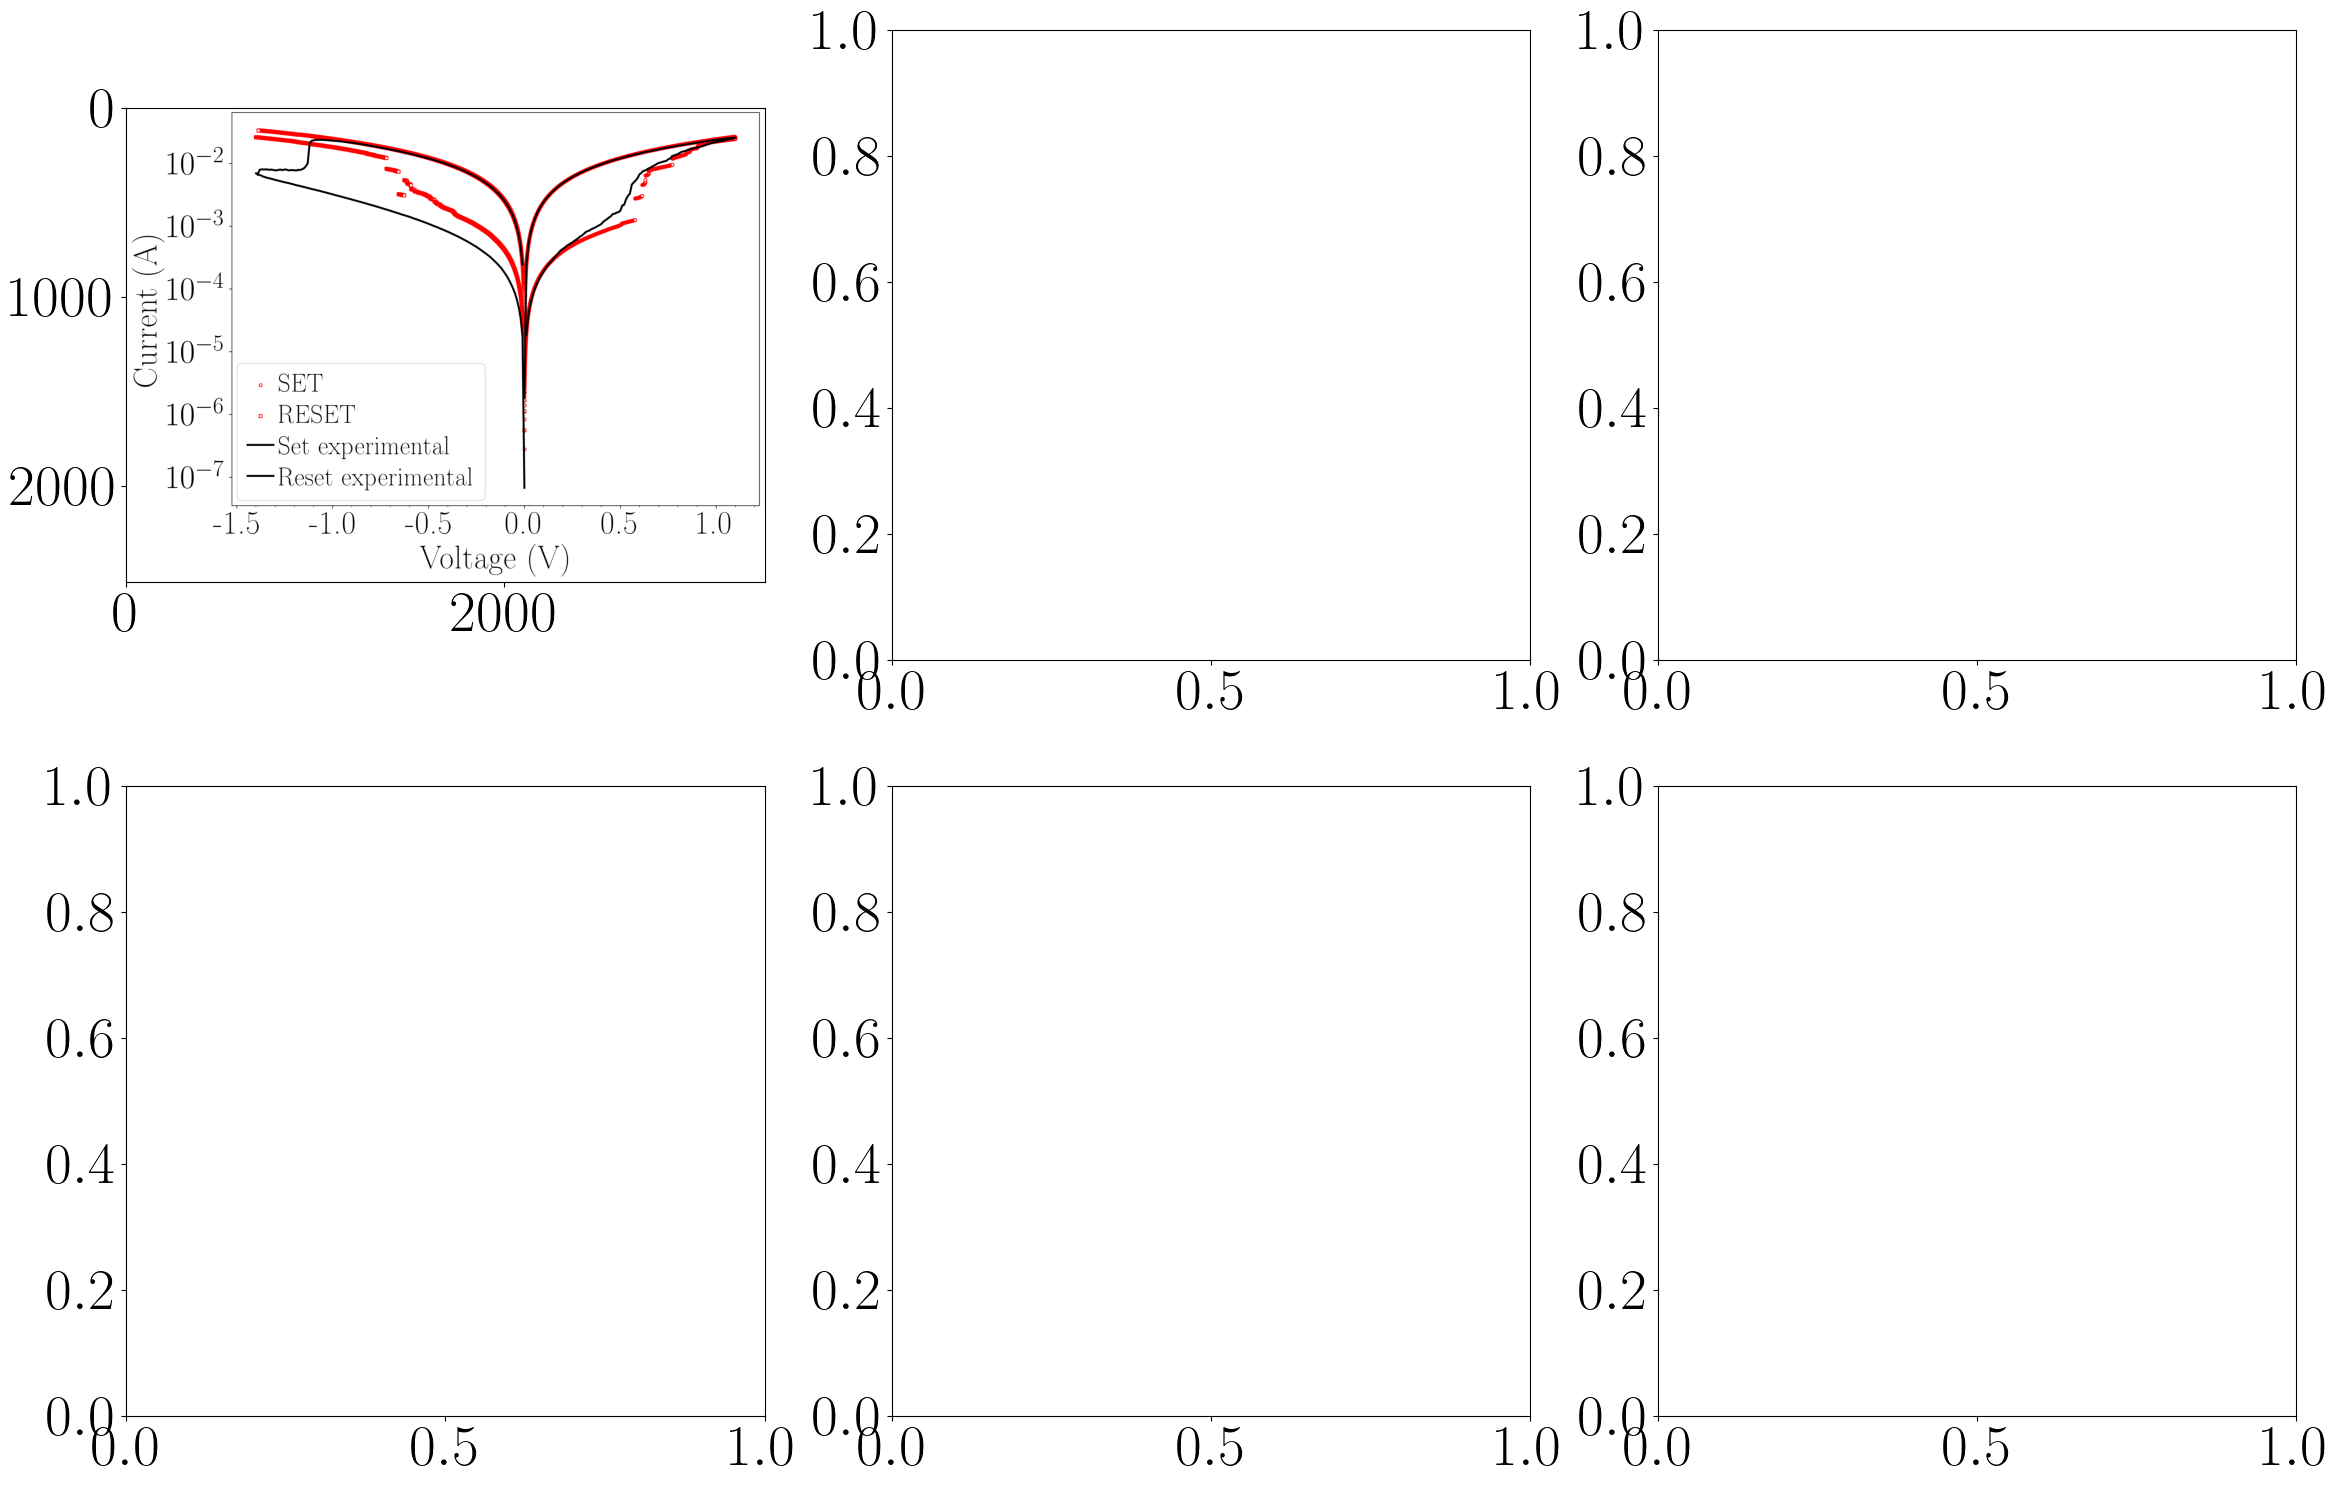

In [10]:
import matplotlib.pyplot as plt
import math

E_r_base = 1.04
num_oxigenos_pp_reset_1 = [1, 2, 3, 4, 5, 6]
num_oxigenos_pp_reset_2 = [7, 8, 9]
num_oxigenos_sp_reset = [10, 11, 12]

indice_pp_reset_2 = 0
indice_sp_reset = 0

num_paneles = math.ceil(num_simulaciones / 4)
num_simulacion = 1

simulation_path = Path.cwd() / "Results" 
figures_path = Path.cwd() / "Results" / "Figures" / "Panels"

os.makedirs(figures_path)

for num_simulation in range(1, num_simulaciones + 1, 6):
    
    print(
        f"Generando figura para el panel {num_simulation}-{num_simulation + len(num_oxigenos_pp_reset_1)-1}"
    )
    
    imagenes = []
    for i in range(len(num_oxigenos_pp_reset_1)):
        ruta = simulation_path / "Figures/" / f"I-V_{num_simulation + i}.png"
        imagenes.append(ruta)
        print(ruta)
    
    # Ejemplo de cómo crear una figura con subplots
    # Si tus figuras ya existen como Axes, los puedes ubicar así:
    fig, axs = plt.subplots(2, 3, figsize=(28, 18))
    
    # Configuración de la figura
    Representate.setup_paper_plt(plt, latex=True, scaling=3)

    if indice_pp_reset_2 == len(num_oxigenos_pp_reset_2):
        indice_sp_reset = indice_sp_reset + 1
        indice_pp_reset_2 = 0
 
    for idx, ax in enumerate(axs.flat):
        if idx < len(imagenes):
            print(f"Cargando imagen: {imagenes[idx]}")
            img_path = imagenes[idx]
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
                ax.imshow(img)
                title = rf"$E_r = {E_r_base}, \text{{1 pp reset}} = {num_oxigenos_pp_reset_1[idx]}, \text{{2 pp reset}} = {num_oxigenos_pp_reset_2[indice_pp_reset_2]}, \text{{Num sp reset}} = {num_oxigenos_sp_reset[indice_sp_reset]}$"
                ax.set_title(title, fontsize=20)
            else:
                ax.text(
                    0.5, 0.5, "Imagen no encontrada", ha="center", va="center", fontsize=10
                )
            ax.axis("off")
        else:
            ax.axis("off")

    indice_pp_reset_2 = indice_pp_reset_2 + 1
    
    plt.tight_layout()
    output_path = (
        figures_path
        / f"State_grupal_{num_simulation}-{num_simulation + len(num_oxigenos_pp_reset_1)-1} .png"
    )
    plt.savefig(output_path, dpi=300)
    plt.close()
    print("\n")
 

In [ ]:
# Copio al backup los resultados y logs de la simulación actual con hora y dia
backup_path = "C:/Users/Usuario/Documents/Backup"

# Obtener fecha y hora actual
ahora = datetime.now()

# Formatear con strftime
formato = "%d-%m_%Y__%H_%M_%S"
fecha_formateada = ahora.strftime(formato)

# creo la carpeta de destino en el backup
backup_path_results = Path(backup_path) / f"Resultados_{fecha_formateada}"
backup_path_logs = Path(backup_path) / f"Logs_{fecha_formateada}"

source_path_results = Path.cwd() / "Results"
source_path_logs = Path.cwd() / "Logs"

destination_results_path = Path(backup_path_results)
destination_logs_path = Path(backup_path_logs)


# Copiar todo el directorio de la simulación al backup
shutil.copytree(source_path_results, destination_results_path)
shutil.copytree(source_path_logs, destination_logs_path)

print(f"Datos de la simulación guardados en el backup.")